## Business objective
- Management wants to understand
  - Olist's sales performance,
  - customers,
  - products, and
  - delivery experience
## so they can identify areas for improvement.

In [41]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [2]:
conn = sqlite3.connect('olist.db')

In [3]:
table = pd.read_sql_query('''
SELECT name FROM sqlite_master 
WHERE type = 'table'
''', conn)

In [4]:
table

,name
0,olist_customers_dataset
1,olist_geolocation_dataset
2,olist_orders_dataset
3,olist_order_items_dataset
4,olist_order_payments_dataset
5,olist_order_reviews_dataset
6,olist_products_dataset
7,olist_sellers_dataset
8,product_category_name_translation


In [5]:
order_items = pd.read_sql_query('''
SELECT * FROM olist_order_items_dataset
limit 5
''',conn)

In [6]:
order_items

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


How did total orders, revenue, and average order value change over time?

In [8]:
totalorders = pd.read_sql_query('''
SELECT COUNT(order_id) FROM olist_order_items_dataset
''', conn)

In [9]:
totalorders

,COUNT(order_id)
0,112650


In [20]:
orderovertime = pd.read_sql_query('''
SELECT DATE(shipping_limit_date) AS DATE, COUNT(order_id) as orders FROM olist_order_items_dataset
GROUP BY DATE(shipping_limit_date)
''', conn);
df = orderovertime
df.head()

,DATE,orders
0,2016-09-19,4
1,2016-10-08,9
2,2016-10-09,12
3,2016-10-10,62
4,2016-10-11,52


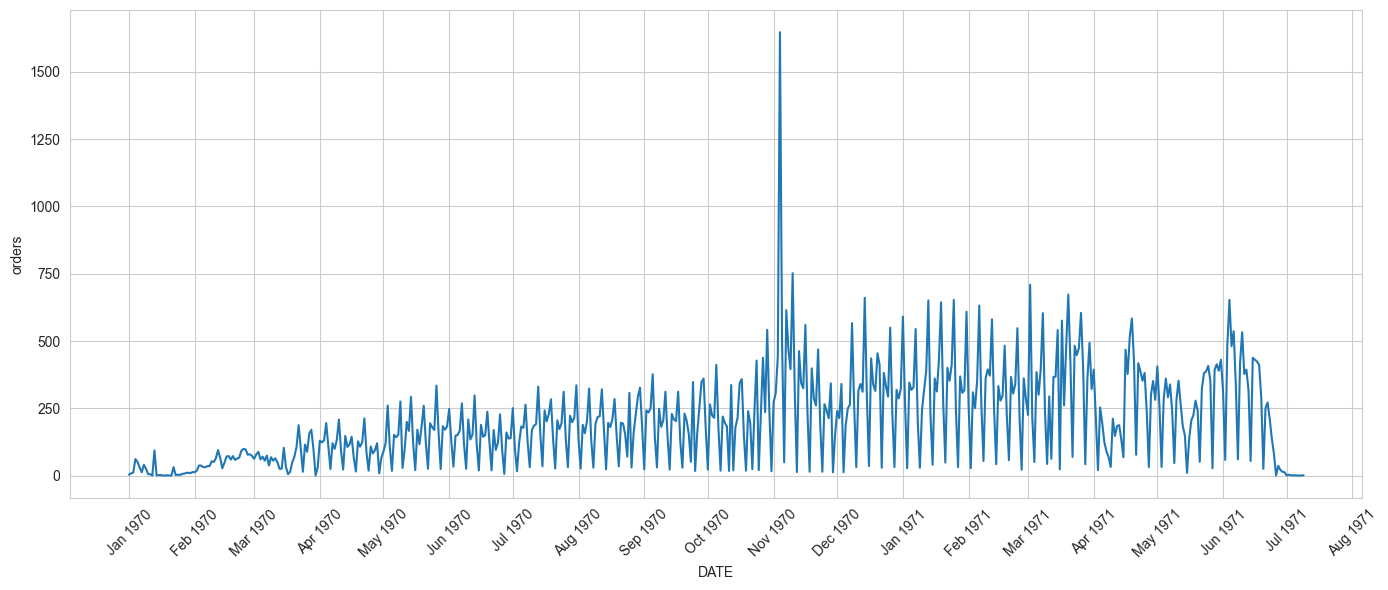

In [50]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.lineplot(x=df['DATE'], y=df['orders'], data=df, ax=ax)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation= 45) 
plt.tight_layout()
plt.show()